# Final Demo — Elastic DAS Project

This notebook provides a compact, reproducible demonstration of the final project workflow:

1. analytical point-force validation,
2. backend benchmark (NumPy vs Numba fused),
3. summary of key results.

**Recommended run location:** the repository root.


## 1. Setup

This notebook assumes the repository structure:

- `src/`
- `scripts/`
- `results/`

If you are not running from the repository root, update `PROJECT_ROOT` below.


In [1]:
from pathlib import Path
import subprocess
import sys
from IPython.display import Image, display, Markdown

cwd = Path.cwd()

if (cwd / "src").exists() and (cwd / "scripts").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").exists() and (cwd.parent / "scripts").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise RuntimeError(
        "Run this notebook from the repository root or from notebooks/."
    )

print('PROJECT_ROOT =', PROJECT_ROOT)
print('Has src      :', (PROJECT_ROOT / 'src').exists())
print('Has scripts  :', (PROJECT_ROOT / 'scripts').exists())
print('Has results  :', (PROJECT_ROOT / 'results').exists())


PROJECT_ROOT = /home/groups/ettore88/alina/classes/geophys245/Elastic_das_project
Has src      : True
Has scripts  : True
Has results  : True


## 2. Analytical validation

This runs the homogeneous point-force validation and generates:

- analytical vs numerical trace comparison,
- zoom around arrivals,
- convergence plot for FD orders 2, 4, 6, 8.


In [ ]:
subprocess.run(
    [sys.executable, '-m', 'scripts.validate_pointforce_2d'],
    cwd=PROJECT_ROOT,
    check=True,
)

Validation geometry
  Source   (ix,iz) = (300,300)  (x,z) = (4500.0,4507.5) m
  Receiver (ix,iz) = (450,450)  (x,z) = (6750.0,6757.5) m
  r = 3182.0 m = 15.9 λ_P
  t_P ≈ 1.061 s
  t_S ≈ 1.872 s
  dt = 2.4819e-04 s,  nt = 12000,  T_total = 2.978 s

Running spatial order 2 (half_order=1) ...

Running spatial order 4 (half_order=2) ...

Running spatial order 6 (half_order=3) ...


### Analytical vs numerical traces

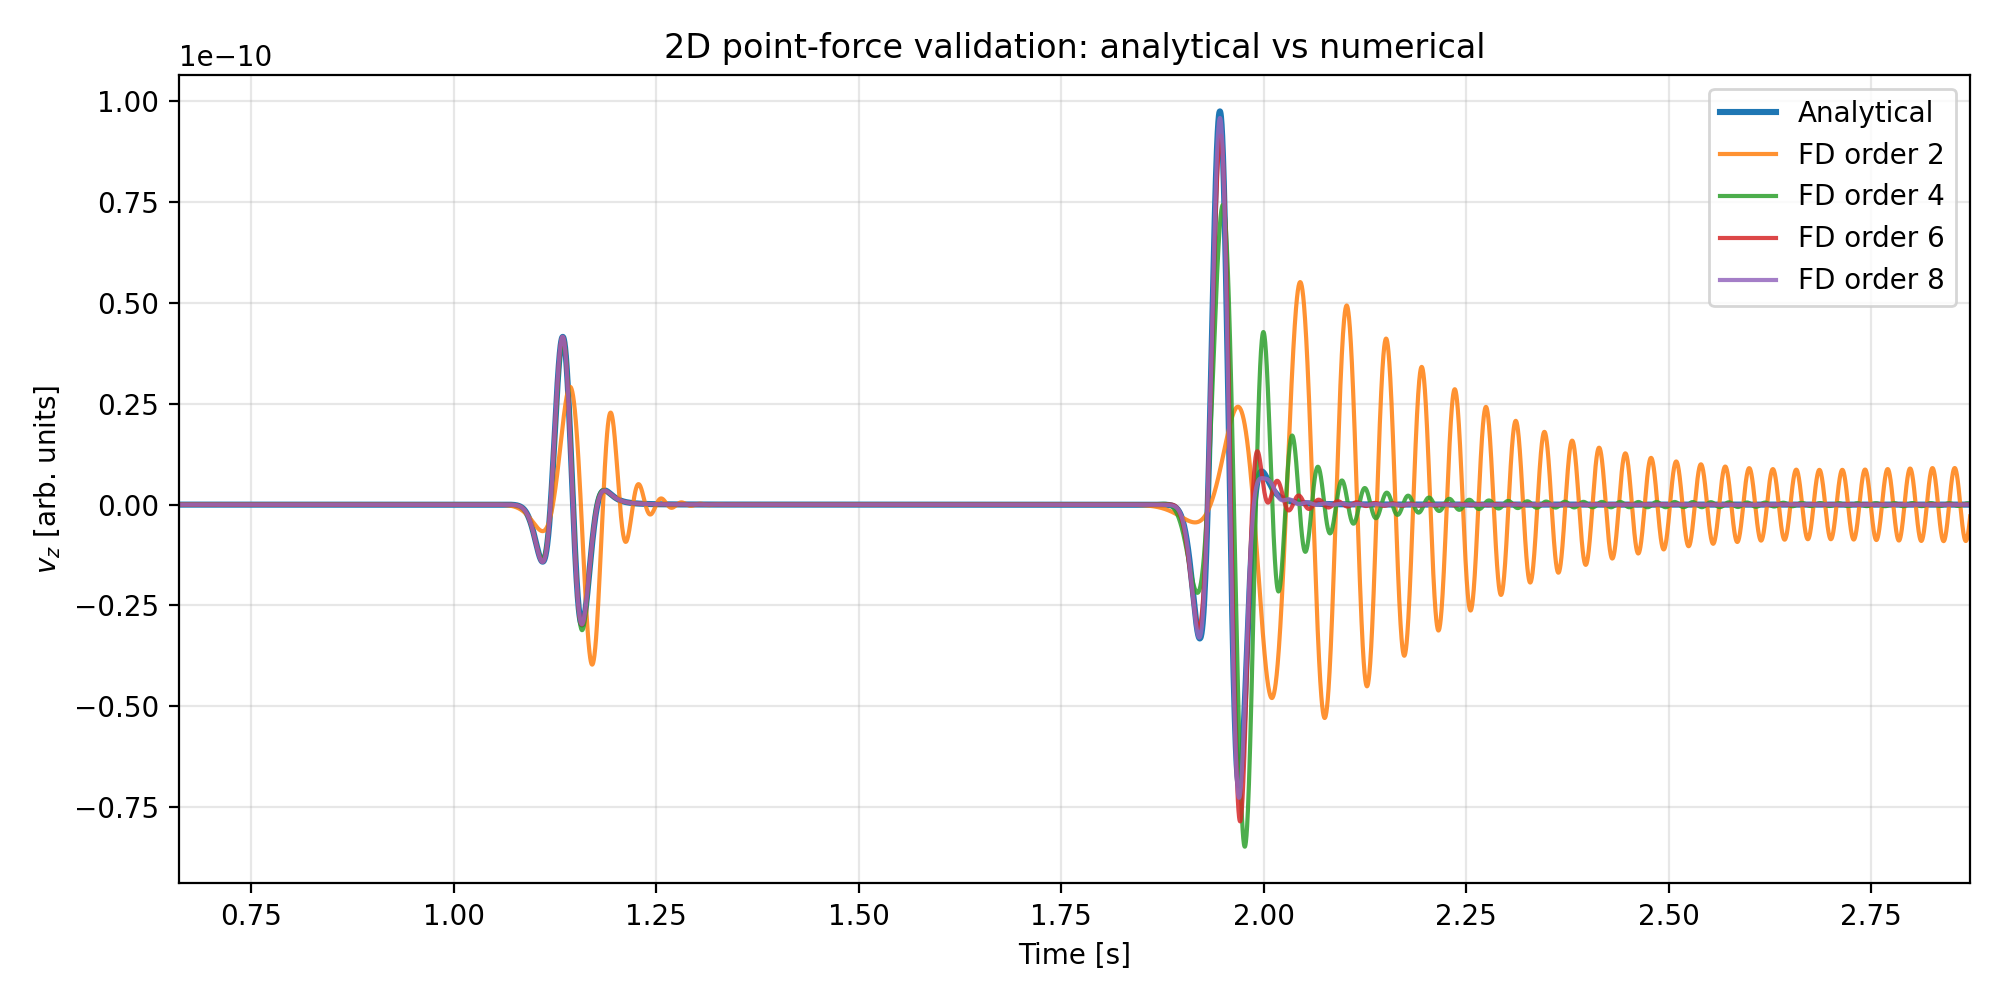

### Zoom around arrivals

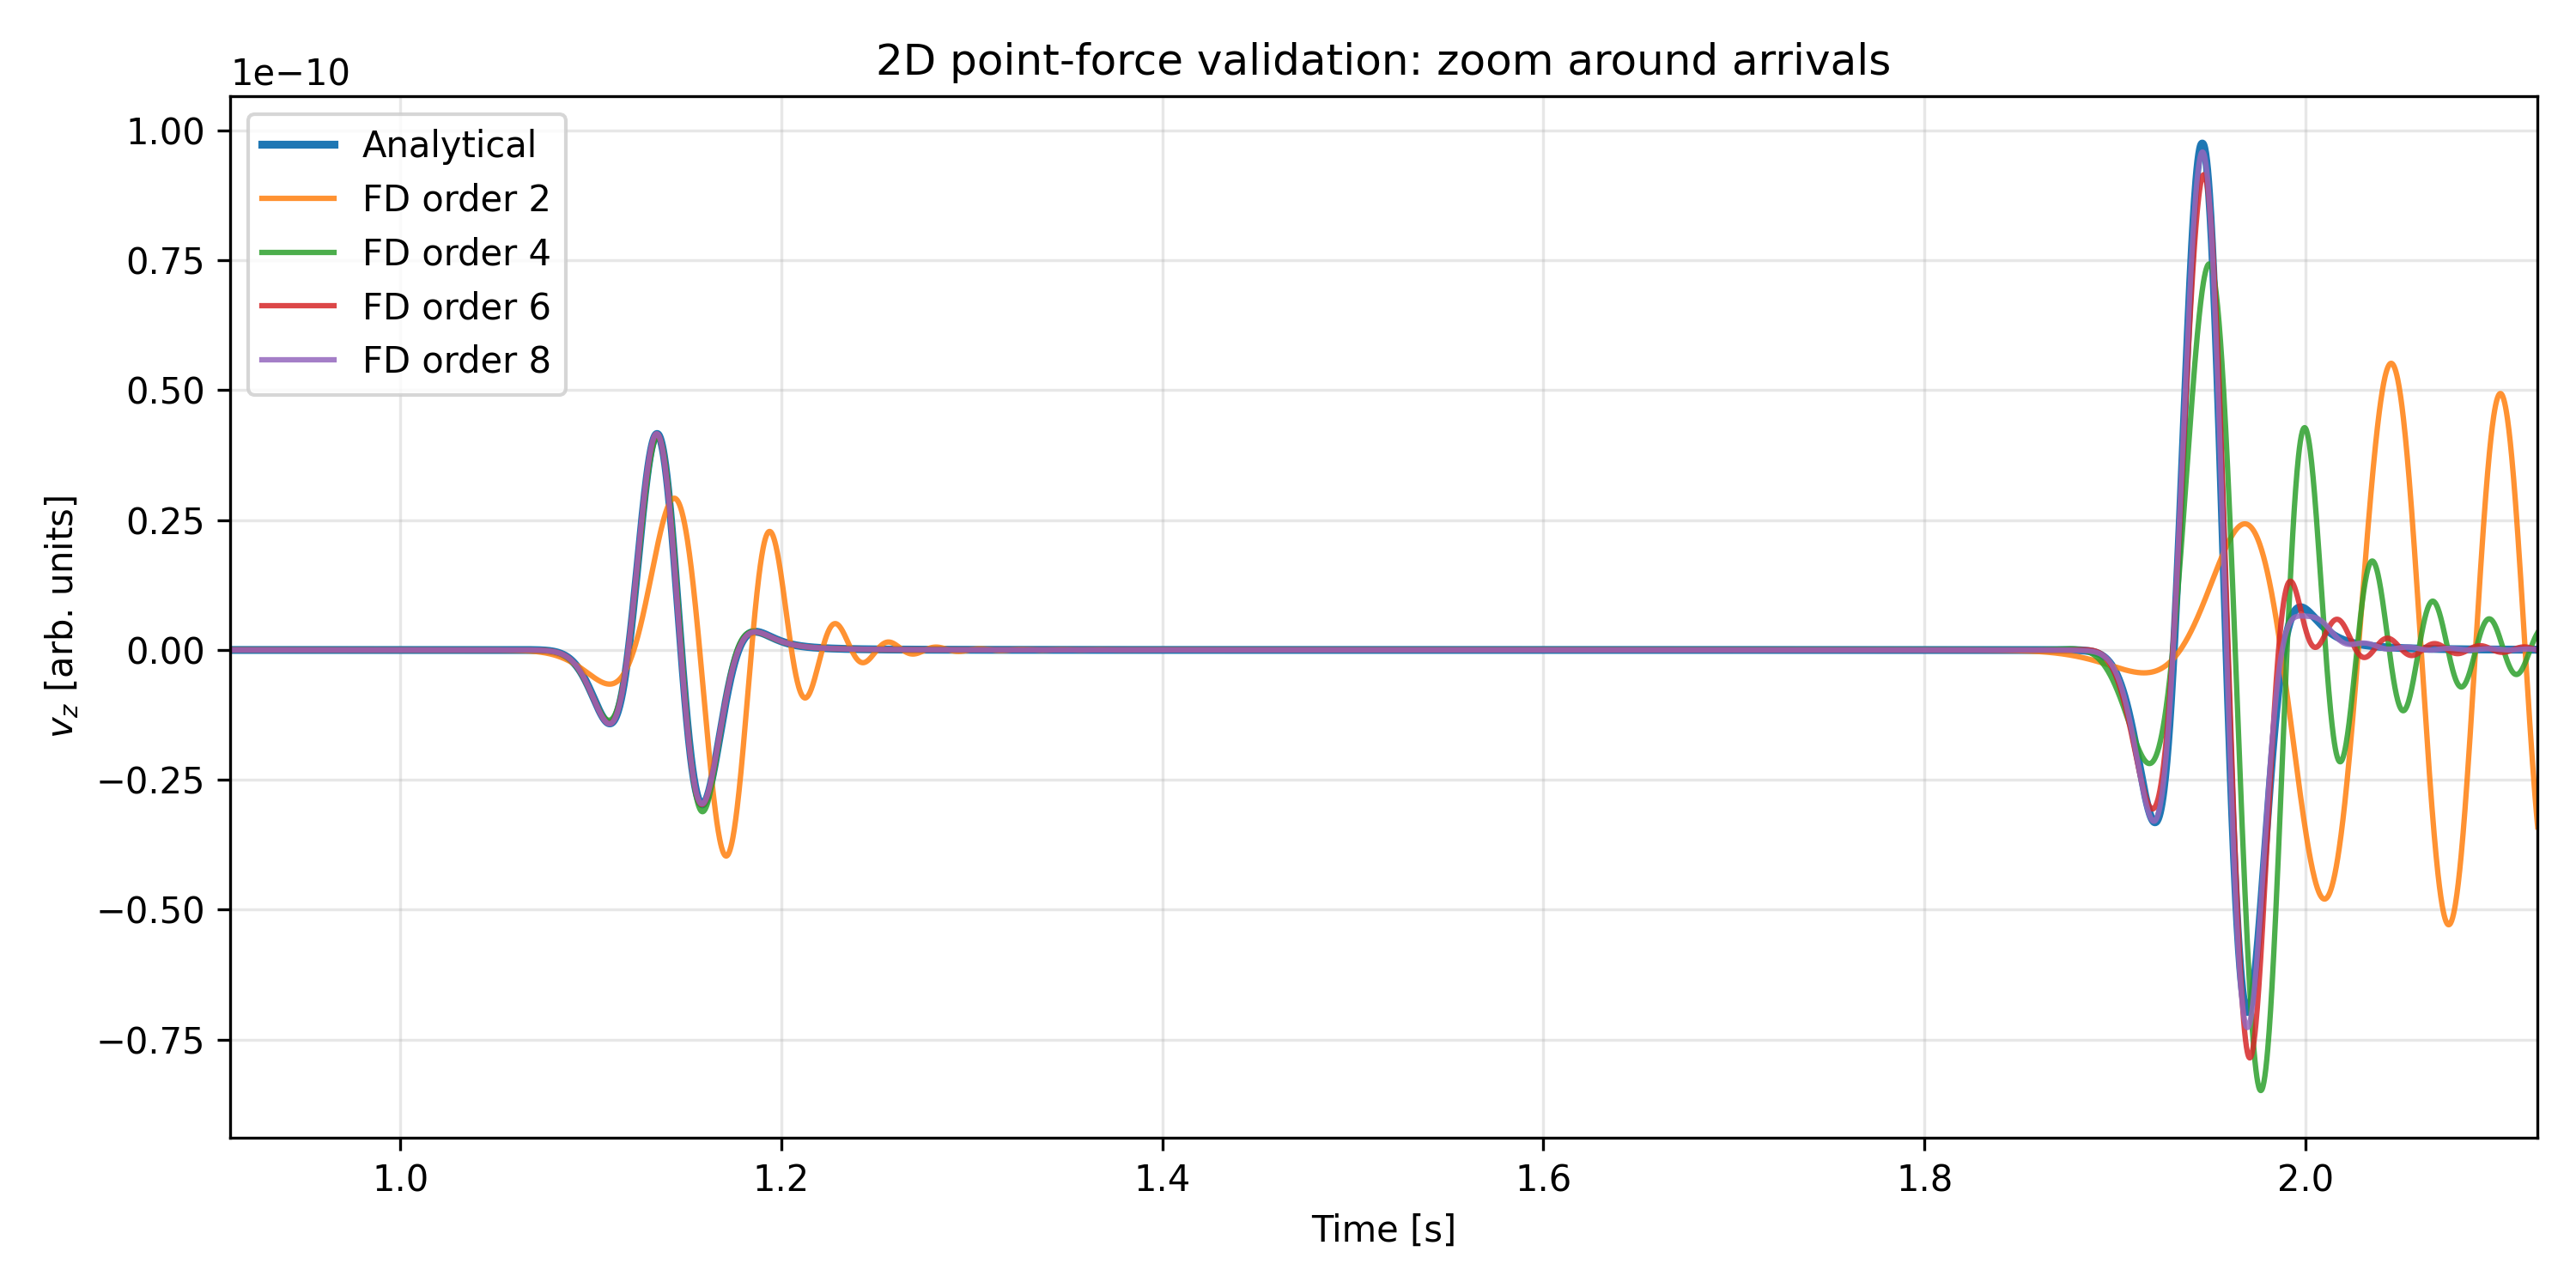

### Convergence with spatial FD order

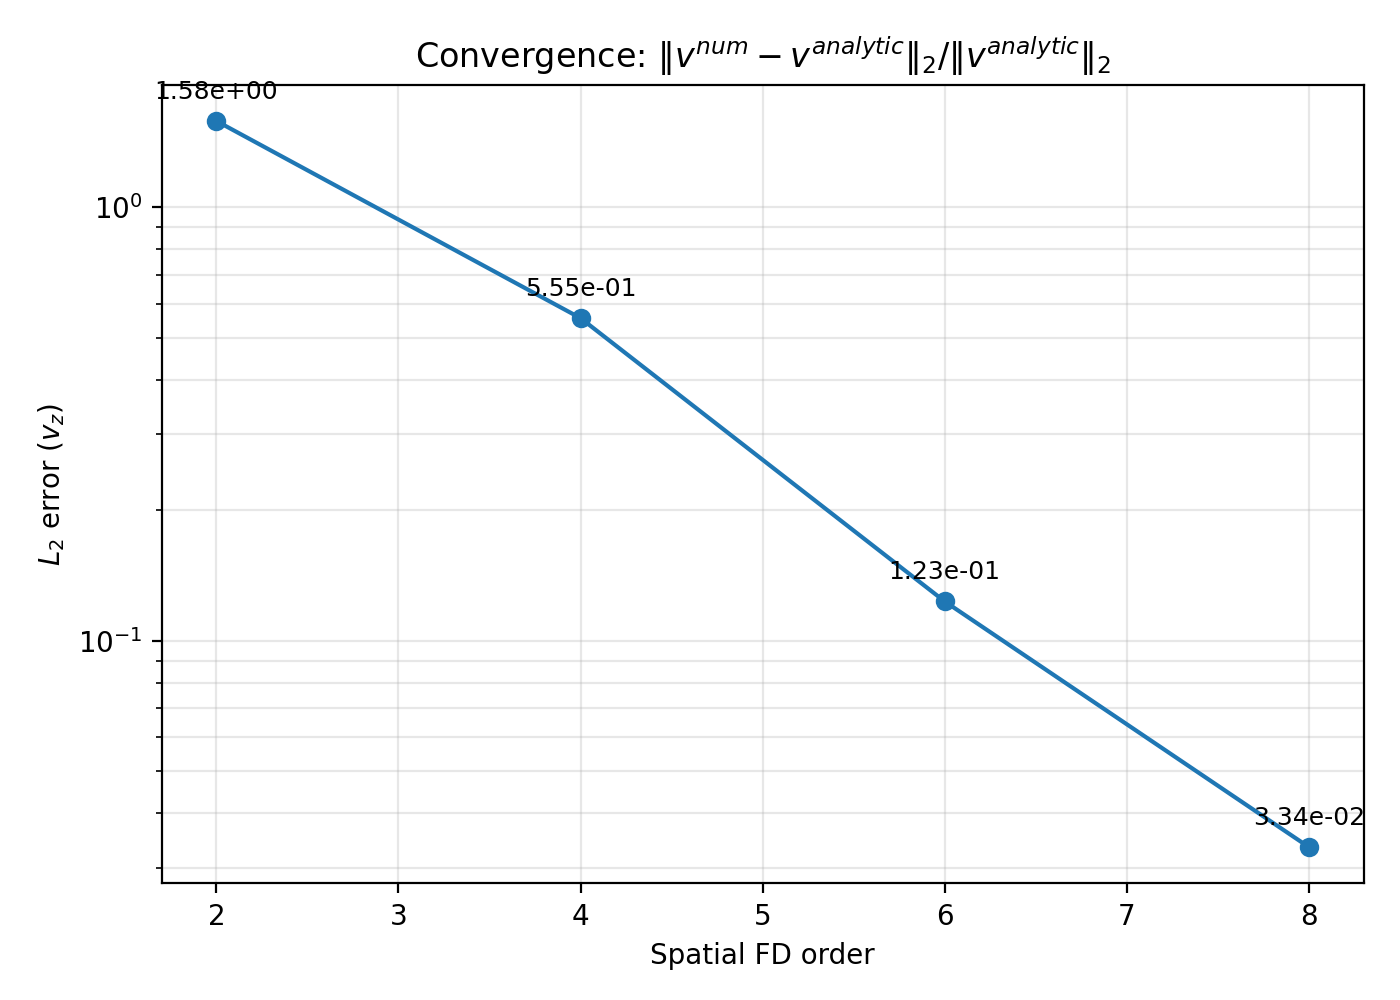

In [ ]:
validation_dir = PROJECT_ROOT / 'results' / 'pointforce_validation'
display(Markdown('### Analytical vs numerical traces'))
display(Image(filename=str(validation_dir / 'pointforce_validation_traces.png')))

display(Markdown('### Zoom around arrivals'))
display(Image(filename=str(validation_dir / 'pointforce_validation_traces_zoom.png')))

display(Markdown('### Convergence with spatial FD order'))
display(Image(filename=str(validation_dir / 'pointforce_validation_error_vs_order.png')))


## 3. Backend benchmark

This compares the NumPy baseline with the Numba fused backend in the free-surface workflow.


In [ ]:
subprocess.run(
    [sys.executable, '-m', 'scripts.benchmark_backends'],
    cwd=PROJECT_ROOT,
    check=True,
)


Warm-up Numba backend...

Benchmark setup: nx=601, nz=601, nt=800, order=4, ts_sfd=False

Benchmark case: free_surface=False
Running NumPy backend (3 runs)...
Running Numba fused backend (3 runs)...

--- Correctness vs NumPy: Numba fused ---
t_v   match: True
t_sig match: True
receiver_vx: max_abs=1.231e-76  rel_L2=8.227e-46  allclose=True
receiver_vz: max_abs=8.906e-78  rel_L2=6.388e-47  allclose=True
DAS data   : max_abs=3.068e-79  rel_L2=1.203e-48  allclose=True

--- Runtime (best of 3) ---
NumPy       : 14.310 s
Numba fused : 0.689 s

--- Speedup over NumPy ---
Numba fused : 20.76x

Benchmark case: free_surface=True
Running NumPy backend (3 runs)...
Running Numba fused backend (3 runs)...

--- Correctness vs NumPy: Numba fused ---
t_v   match: True
t_sig match: True
receiver_vx: max_abs=1.209e-76  rel_L2=6.162e-46  allclose=True
receiver_vz: max_abs=9.311e-78  rel_L2=5.414e-47  allclose=True
DAS data   : max_abs=1.961e-79  rel_L2=8.705e-49  allclose=True

--- Runtime (best of 3) --

CompletedProcess(args=['/home/groups/ettore88/alina/.envs/fwi/bin/python', '-m', 'scripts.benchmark_backends'], returncode=0)

## 4. Performance plots

Generate summary runtime and speedup figures.


In [ ]:
subprocess.run(
    [sys.executable, "-m", "scripts.run_performance_study"],
    cwd=PROJECT_ROOT,
    check=True,
)

/home/groups/ettore88/alina/.envs/fwi/bin/python: No module named scripts.plot_backend_performance


CalledProcessError: Command '['/home/groups/ettore88/alina/.envs/fwi/bin/python', '-m', 'scripts.plot_backend_performance']' returned non-zero exit status 1.

In [ ]:
fig_path = PROJECT_ROOT / "results" / "final_figures" / "performance_summary_free_surface_true.png"

if fig_path.exists():
    display(Image(filename=str(fig_path)))
else:
    display(Markdown(
        "Performance figure not found. Run `python -m scripts.run_performance_study` first."
    ))

## 5. Final takeaway

- The 2D staggered-grid elastic solver was validated against an analytical point-force reference.
- The numerical solution converges toward the analytical trace as the spatial FD order increases.
- The Numba fused backend reproduces the NumPy baseline while providing substantial runtime speedup.
- The workflow is reproducible and can be used as a compact demonstration of the final project.
